## 1. Load Corpora
Download and load the Wikipedia and Stack Exchange politeness corpora from ConvoKit.

In [11]:
from convokit import Corpus, download
# https://convokit.cornell.edu/documentation/stack_politeness.html for mor details
corpus_wiki = Corpus(filename=download("wikipedia-politeness-corpus"))
corpus_stack = Corpus(filename=download("stack-exchange-politeness-corpus"))
corpus_awry = Corpus(filename=download("conversations-gone-awry-corpus"))

Dataset already exists at /Users/yuka/.convokit/saved-corpora/wikipedia-politeness-corpus
Dataset already exists at /Users/yuka/.convokit/saved-corpora/stack-exchange-politeness-corpus


## 2. Explore Corpus Data
Inspect utterance metadata (scores, annotations) and corpus size.

In [17]:
len(corpus_awry.get_utterance_ids()),len(corpus_wiki.get_utterance_ids()),len(corpus_stack.get_utterance_ids())

(30021, 4353, 6603)

In [23]:
utterance_list = []
modifier_list = ["a bit", "a little", "somewhat","slightly","kinda","sorta","very","really","extremely","super","totally","completely","absolutely","utterly","immensely"]
modifier_wiki_requests_count = {modifier: 0 for modifier in modifier_list}
modifier_awry_count = {modifier: 0 for modifier in modifier_list}
modifier_stack_count = {modifier: 0 for modifier in modifier_list}
for i, utt in enumerate(corpus_wiki.iter_utterances()):
    for modifier in modifier_list:
        if (utt.text.find(modifier) != -1):
            utterance_list.append((utt.text,utt.meta["Normalized Score"]))
            modifier_wiki_requests_count[modifier] += 1/ len(corpus_wiki.get_utterance_ids())
for i, utt in enumerate(corpus_awry.iter_utterances()):
    for modifier in modifier_list:
        if (utt.text.find(modifier) != -1):
            modifier_awry_count[modifier] += 1/ len(corpus_awry.get_utterance_ids())
for i, utt in enumerate(corpus_stack.iter_utterances()):
    for modifier in modifier_list:
        if (utt.text.find(modifier) != -1):
            modifier_stack_count[modifier] += 1/len(corpus_stack.get_utterance_ids())
# save as a csv
import csv
with open('modifier_wiki_requests_count.csv', 'w', newline='') as csvfile:
    writer = csv.writer(csvfile)
    writer.writerow(['Modifier', 'Count'])  # Write header
    for modifier, count in modifier_wiki_requests_count.items():
        writer.writerow([modifier, count])  # Write data rows
with open('modifier_awry_count.csv', 'w', newline='') as csvfile:
    writer = csv.writer(csvfile)
    writer.writerow(['Modifier', 'Count'])  # Write header
    for modifier, count in modifier_awry_count.items():
        writer.writerow([modifier, count])  # Write data rows

In [24]:
len(corpus_wiki.get_utterance_ids()),len(corpus_awry.get_utterance_ids()),modifier_wiki_requests_count,modifier_awry_count,modifier_stack_count

(4353,
 30021,
 {'a bit': 0.014472777394900046,
  'a little': 0.008959338387319087,
  'somewhat': 0.0016080863772111188,
  'slightly': 0.0006891798759476223,
  'kinda': 0.0006891798759476223,
  'sorta': 0,
  'very': 0.03170227429359066,
  'really': 0.024121295658166786,
  'extremely': 0.0006891798759476223,
  'super': 0.002526992878474615,
  'totally': 0.002297266253158741,
  'completely': 0.00390535263036986,
  'absolutely': 0.002526992878474615,
  'utterly': 0.0006891798759476223,
  'immensely': 0},
 {'a bit': 0.013590486659338371,
  'a little': 0.009693214749675216,
  'somewhat': 0.0047966423503547646,
  'slightly': 0.0031977615669031728,
  'kinda': 0.0008660604243696076,
  'sorta': 0.000299790146897172,
  'very': 0.10426035108757765,
  'really': 0.04753339329136361,
  'extremely': 0.005029812464608122,
  'super': 0.00742813363978551,
  'totally': 0.007161653509210245,
  'completely': 0.014156756936810795,
  'absolutely': 0.007361513607141694,
  'utterly': 0.0015655707671296747,
  '

In [9]:

import json
from google import genai
from google.genai import types
import os
import pandas as pd
import random
from dotenv import load_dotenv
load_dotenv()
client = genai.Client(
    api_key=os.getenv("google_api_key"),
)

## 3. Label Modifiers with Gemini (Wikipedia)
Use the Gemini API to classify each Wikipedia utterance as containing a modifier or not.

In [26]:

sentence = ""
responses = []
for index,utt in enumerate(utterance_list):
    sentence += f"{index+1}. " + utt[0]
    sentence += "\n"
    if index %30== 29:
        print(index)
        break
response = client.models.generate_content(
    model="gemini-3-flash-preview",
    contents="For each of these sentences, output how polite the sentence is on a scale from 0 to 10:\n"+sentence
)     
responses.append(response.text)


29


In [27]:
print(sentence)
print(responses)

1. Can you explain more in detail, what should I sddelat? Allocate a job? How?
2. Will expressions always be unambiguously parenthesized like that, so you don't have to deal with precedence? Or is `X OR Y AND Z` allowed?
3. how are you resolving function pointers? I am also writing similar kind of program but still wondering how i will resolve function pointers?
4. What is the definition of `buffer`? Is it a local variable?
5. Is `A` a global variable?  What is x?
6. This is a very confusing question!  How are you compiling your C programs?
7. Why not using `isnan()` from math.h? Any specially reason?
8. @Foon I just know that to compile in Linux I do gcc or g++ and in Solaris I do cc. Or am I wrong about it?
9. do you want to send the 32bit number in binary form? or in ascii?
10. Does your project involve some graphical user interface? What do you want to code?
11. What have you tried? Where are you finding a problem?
12. Usually compilers should generate a good code for such algorith

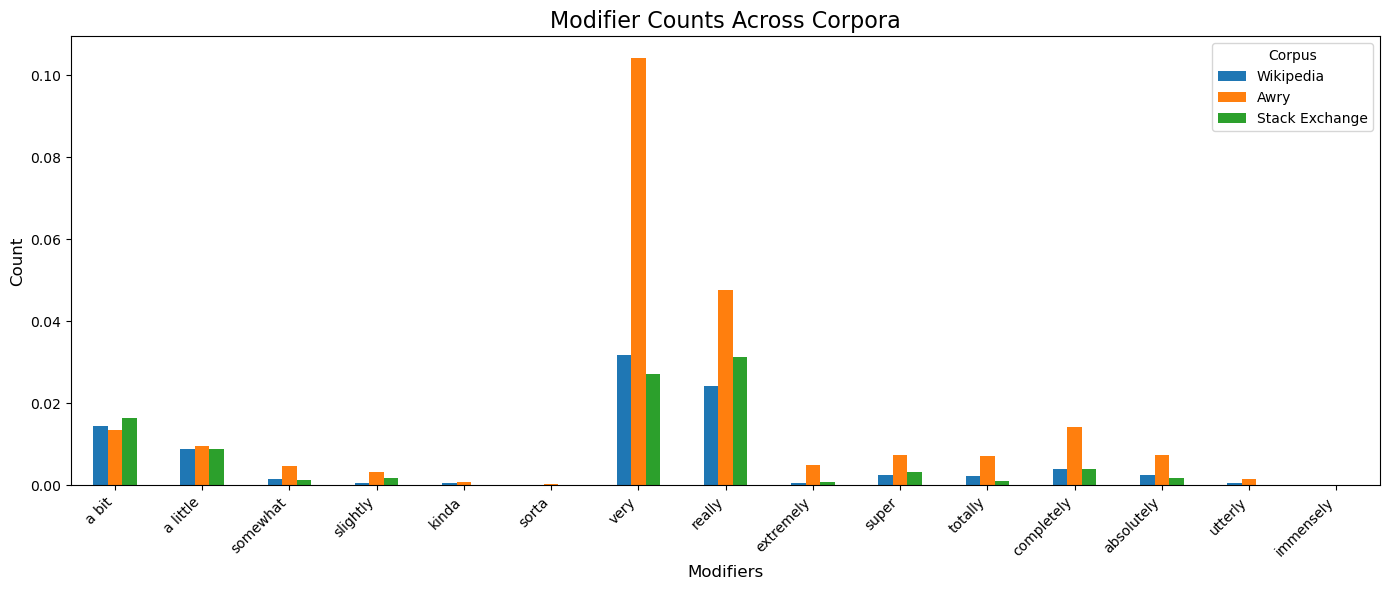

            Wikipedia      Awry  Stack Exchange
a bit        0.014473  0.013590        0.016356
a little     0.008959  0.009693        0.008935
somewhat     0.001608  0.004797        0.001363
slightly     0.000689  0.003198        0.001817
kinda        0.000689  0.000866        0.000151
sorta        0.000000  0.000300        0.000151
very         0.031702  0.104260        0.027109
really       0.024121  0.047533        0.031349
extremely    0.000689  0.005030        0.000757
super        0.002527  0.007428        0.003332
totally      0.002297  0.007162        0.001060
completely   0.003905  0.014157        0.004089
absolutely   0.002527  0.007362        0.001817
utterly      0.000689  0.001566        0.000151
immensely    0.000000  0.000100        0.000151


In [25]:
import pandas as pd
import matplotlib.pyplot as plt

# Create a DataFrame from the three modifier count dictionaries
df = pd.DataFrame({
    'Wikipedia': modifier_wiki_requests_count,
    'Awry': modifier_awry_count,
    'Stack Exchange': modifier_stack_count
})

# Plot the data
fig, ax = plt.subplots(figsize=(14, 6))
df.plot(kind='bar', ax=ax)

ax.set_title('Modifier Counts Across Corpora', fontsize=16)
ax.set_xlabel('Modifiers', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.legend(title='Corpus')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Display the dataframe
print(df)